#  PART B — Practical (Python Programming)

---

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew, kurtosis

In [39]:
df = pd.read_csv("C:\\Users\\tanaa\\Desktop\\loan_applications.csv")
df.head()

,Customer_ID,Age,Income,Loan_Amount,Credit_Score,Loan_Term,Default_Status
0,CUST00001,61,77657,105390,735,24,No
1,CUST00002,64,53676,137771,550,12,Yes
2,CUST00003,34,57657,142087,758,84,No
3,CUST00004,55,37802,55708,692,120,Yes
4,CUST00005,31,49745,51943,581,120,No


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Customer_ID     5200 non-null   str  
 1   Age             5200 non-null   int64
 2   Income          5200 non-null   int64
 3   Loan_Amount     5200 non-null   int64
 4   Credit_Score    5200 non-null   int64
 5   Loan_Term       5200 non-null   int64
 6   Default_Status  5200 non-null   str  
dtypes: int64(5), str(2)
memory usage: 284.5 KB


In [26]:
print("Mean   :", df['Income'].mean())
print("Median :", df['Income'].median())
print("Mode   :", df['Income'].mode()[0])


Mean   : 55115.04769230769
Median : 54909.0
Mode   : 15000


In [27]:
print("Range    :", df['Loan_Amount'].max() - df['Loan_Amount'].min())
print("Variance :", df['Loan_Amount'].var())
print("Std Dev  :", df['Loan_Amount'].std())

Range    : 398479
Variance : 4947855395.894985
Std Dev  : 70340.99370846977


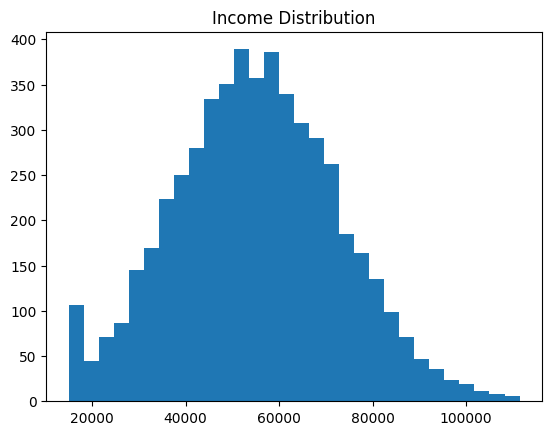

In [41]:
plt.hist(df['Income'], bins=30)
plt.title("Income Distribution")
plt.show()

In [42]:
total = len(df)
defaults = (df['Default_Status'] == 'Yes').sum()

print("\n--- Default Probability ---")
print("Total:", total)
print("Defaults:", defaults)
print("P(Default):", defaults / total)



--- Default Probability ---
Total: 5200
Defaults: 1815
P(Default): 0.3490384615384615


In [45]:
def credit_category(score):
    if score < 580:
        return 'Poor'
    elif score < 670:
        return 'Fair'
    elif score < 740:
        return 'Good'
    elif score < 800:
        return 'Very Good'
    else:
        return 'Excellent'

df['Credit_Category'] = df['Credit_Score'].apply(credit_category)

# Conditional probability
low = df[df['Credit_Score'] < 600]
high = df[df['Credit_Score'] >= 700]

p_low = (low['Default_Status'] == 'Yes').sum() / len(low)
p_high = (high['Default_Status'] == 'Yes').sum() / len(high)

print("\nP(Default | Low Credit):", p_low)
print("P(Default | High Credit):", p_high)

# ===== STEP 3: Distribution =====
mu = df['Credit_Score'].mean()
sigma = df['Credit_Score'].std()

print("\n--- Credit Score ---")
print("Mean:", mu)
print("Std Dev:", sigma)

# Skewness & Kurtosis
print("\n--- Loan Distribution Shape ---")
print("Skewness:", skew(df['Loan_Amount']))
print("Kurtosis:", kurtosis(df['Loan_Amount']))

# ===== STEP 4: Vectors =====
vectors = df[['Income', 'Loan_Amount']].head(2).values
v1 = vectors[0]
v2 = vectors[1]

print("\n--- Vectors ---")
print("v1:", v1)
print("v2:", v2)

# Dot product
dot = np.dot(v1, v2)
print("Dot Product:", dot)

# Norm
norm1 = np.linalg.norm(v1)
norm2 = np.linalg.norm(v2)

print("||v1||:", norm1)
print("||v2||:", norm2)

# Angle
cos_theta = dot / (norm1 * norm2)
angle = np.degrees(np.arccos(cos_theta))

print("Angle (degrees):", angle)

# ===== FINAL SUMMARY =====
print("\n===== FINAL SUMMARY =====")
print("Income Mean:", df['Income'].mean())
print("Default Rate:", defaults / total)
print("Loan Skewness:", skew(df['Loan_Amount']))
print("Credit Score Mean:", mu)
print("Angle:", angle)
print("=========================")


P(Default | Low Credit): 0.5404040404040404
P(Default | High Credit): 0.18658280922431866

--- Credit Score ---
Mean: 649.8773076923077
Std Dev: 79.71033310526434

--- Loan Distribution Shape ---
Skewness: 0.6930780383304281
Kurtosis: -0.03859270702073081

--- Vectors ---
v1: [ 77657 105390]
v2: [ 53676 137771]
Dot Product: 18688002822
||v1||: 130910.89240013606
||v2||: 147857.9095517044
Angle (degrees): 15.09873898796453

===== FINAL SUMMARY =====
Income Mean: 55115.04769230769
Default Rate: 0.3490384615384615
Loan Skewness: 0.6930780383304281
Credit Score Mean: 649.8773076923077
Angle: 15.09873898796453


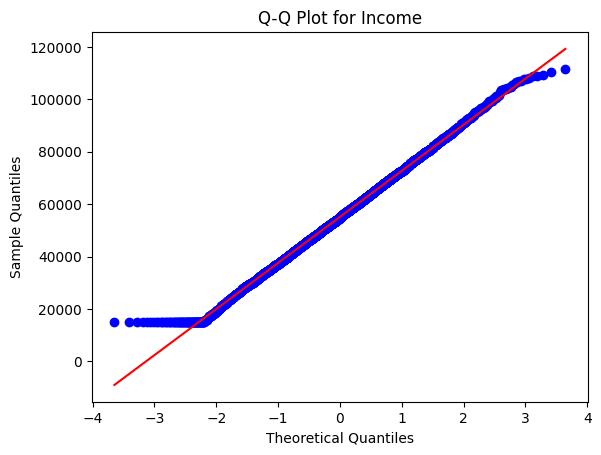

In [46]:


# Q-Q Plot
stats.probplot(df['Income'], dist='norm', plot=plt)

plt.title("Q-Q Plot for Income")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.show()

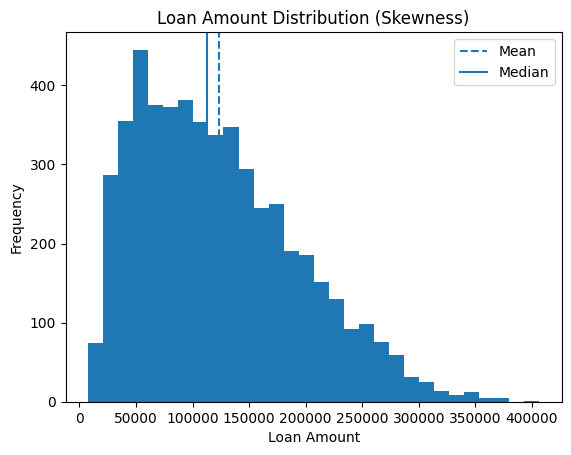

In [47]:
import matplotlib.pyplot as plt

# Histogram
plt.hist(df['Loan_Amount'], bins=30)

# Mean & Median lines
plt.axvline(df['Loan_Amount'].mean(), linestyle='--', label='Mean')
plt.axvline(df['Loan_Amount'].median(), linestyle='-', label='Median')

plt.title("Loan Amount Distribution (Skewness)")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.legend()

plt.show()